# AI Programming Foundations Project — Data Workflow

**Author:** Paolo Ghidoni  
**Dataset:** Iris Flower Measurements — [UCI Machine Learning Repository](https://archive.ics.uci.edu/dataset/53/iris)  

## Project Description

This notebook presents a complete, reproducible data science workflow applied to the classic Iris dataset,
which contains 150 samples of iris flowers across three species, described by four numeric measurements.
The workflow covers data ingestion, cleaning, exploratory analysis, and visualization, and is designed to
serve as a reusable foundation for future machine learning and deep learning projects.
All steps are modular and documented to ensure full reproducibility.

## Setup

Import all required libraries.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Consistent plot style
sns.set_theme(style="whitegrid", palette="Set2")
plt.rcParams["figure.dpi"] = 100

print("Libraries loaded successfully.")
print(f"NumPy {np.__version__} | Pandas {pd.__version__}")

Libraries loaded successfully.
NumPy 2.2.6 | Pandas 2.3.3


## Data Ingestion

Load the Iris dataset from the local CSV file. The dataset contains 150 rows and 5 columns:
`sepal_length`, `sepal_width`, `petal_length`, `petal_width` (all in cm), and `species`.

In [2]:
df = pd.read_csv("iris.csv")

print("Dataset shape:", df.shape)
print("\nFirst 5 rows:")
df.head()

Dataset shape: (150, 5)

First 5 rows:


,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [3]:
print("Column data types:")
print(df.dtypes)
print("\nBasic info:")
df.info()

Column data types:
sepal_length    float64
sepal_width     float64
petal_length    float64
petal_width     float64
species          object
dtype: object

Basic info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB


## Data Cleaning

Before analysis, we apply two cleaning functions to ensure data quality.

**Why cleaning is necessary:**
- Real-world datasets may contain duplicate records that skew summary statistics and model training.
- Missing values in numeric columns would cause errors in statistical computations and visualizations.
  Even though the Iris dataset is already clean, applying these functions demonstrates best practice
  and makes the pipeline robust when applied to noisier datasets in future projects.

In [4]:
def drop_duplicate_rows(dataframe):
    """
    Remove exact duplicate rows from a DataFrame.

    Duplicates can inflate counts, skew summary statistics, and introduce
    bias in downstream models. This function removes all rows that are
    identical across every column, keeping the first occurrence.

    Parameters
    ----------
    dataframe : pd.DataFrame
        The input DataFrame to deduplicate.

    Returns
    -------
    pd.DataFrame
        A new DataFrame with duplicate rows removed.
    """
    before = len(dataframe)
    cleaned = dataframe.drop_duplicates().reset_index(drop=True)
    after = len(cleaned)
    print(f"drop_duplicate_rows: removed {before - after} duplicate(s). Rows: {before} → {after}")
    return cleaned


def fill_missing_numeric(dataframe):
    """
    Impute missing values in numeric columns with the column median.

    Missing values in numeric features break most statistical and
    machine-learning operations. Median imputation is preferred over
    mean imputation because the median is robust to outliers — a
    property especially important for skewed biological measurements.

    Parameters
    ----------
    dataframe : pd.DataFrame
        The input DataFrame that may contain NaN values.

    Returns
    -------
    pd.DataFrame
        A new DataFrame with NaNs in numeric columns replaced by
        the respective column median.
    """
    cleaned = dataframe.copy()
    numeric_cols = cleaned.select_dtypes(include=[np.number]).columns
    missing_before = cleaned[numeric_cols].isnull().sum().sum()
    for col in numeric_cols:
        median_val = cleaned[col].median()
        cleaned[col] = cleaned[col].fillna(median_val)
    missing_after = cleaned[numeric_cols].isnull().sum().sum()
    print(f"fill_missing_numeric: filled {missing_before} missing value(s). Remaining NaNs: {missing_after}")
    return cleaned

In [5]:
# Apply cleaning functions
df = drop_duplicate_rows(df)
df = fill_missing_numeric(df)

print("\nCleaned dataset shape:", df.shape)
print("Missing values remaining:", df.isnull().sum().sum())

drop_duplicate_rows: removed 1 duplicate(s). Rows: 150 → 149
fill_missing_numeric: filled 0 missing value(s). Remaining NaNs: 0

Cleaned dataset shape: (149, 5)
Missing values remaining: 0


## Exploratory Analysis

We define an EDA function that produces summary statistics, species-level grouped views,
and a correlation matrix to identify relationships among numeric features.

In [6]:
def exploratory_analysis(dataframe, target_col="species"):
    """
    Perform exploratory data analysis on the dataset.

    Computes and prints:
    - Overall descriptive statistics for numeric columns.
    - Per-group (species) mean values to highlight inter-class differences.
    - A Pearson correlation matrix for numeric features.

    Parameters
    ----------
    dataframe : pd.DataFrame
        The cleaned DataFrame to analyse.
    target_col : str, optional
        The categorical column used for grouping (default: 'species').

    Returns
    -------
    pd.DataFrame
        The correlation matrix as a DataFrame.
    """
    print("=" * 60)
    print("DESCRIPTIVE STATISTICS")
    print("=" * 60)
    print(dataframe.describe().round(2))

    print("\n" + "=" * 60)
    print(f"MEAN VALUES BY {target_col.upper()}")
    print("=" * 60)
    print(dataframe.groupby(target_col).mean().round(2))

    numeric_df = dataframe.select_dtypes(include=[np.number])
    corr = numeric_df.corr()
    print("\n" + "=" * 60)
    print("CORRELATION MATRIX")
    print("=" * 60)
    print(corr.round(2))

    return corr


corr_matrix = exploratory_analysis(df)

DESCRIPTIVE STATISTICS
       sepal_length  sepal_width  petal_length  petal_width
count        149.00       149.00        149.00       149.00
mean           5.84         3.06          3.75         1.19
std            0.83         0.44          1.77         0.76
min            4.30         2.00          1.00         0.10
25%            5.10         2.80          1.60         0.30
50%            5.80         3.00          4.30         1.30
75%            6.40         3.30          5.10         1.80
max            7.90         4.40          6.90         2.50

MEAN VALUES BY SPECIES
            sepal_length  sepal_width  petal_length  petal_width
species                                                         
setosa              5.01         3.43          1.46         0.25
versicolor          5.94         2.77          4.26         1.33
virginica           6.60         2.98          5.56         2.03

CORRELATION MATRIX
              sepal_length  sepal_width  petal_length  petal_width
s

## Visualizations

Three visualizations are created to communicate the most important patterns in the dataset.
Each plot includes a title and labeled axes.

### Figure 1 — Petal Length Distribution by Species

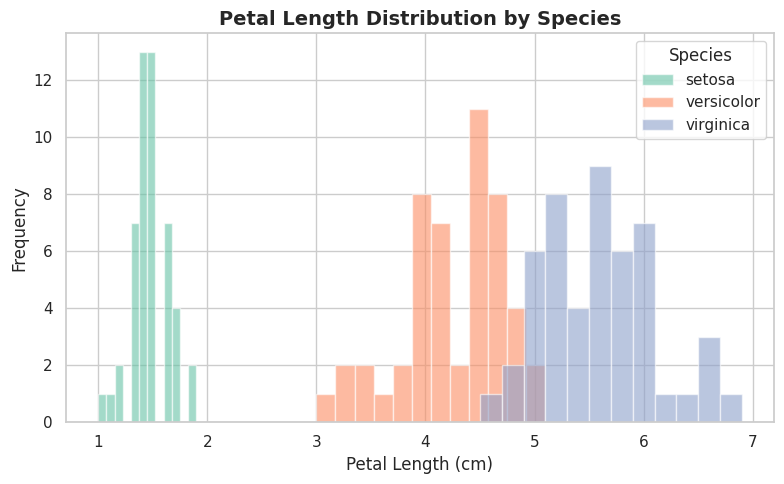

Figure 1 saved.


In [7]:
fig, ax = plt.subplots(figsize=(8, 5))

for species, group in df.groupby("species"):
    ax.hist(group["petal_length"], bins=12, alpha=0.6, label=species, edgecolor="white")

ax.set_title("Petal Length Distribution by Species", fontsize=14, fontweight="bold")
ax.set_xlabel("Petal Length (cm)", fontsize=12)
ax.set_ylabel("Frequency", fontsize=12)
ax.legend(title="Species")
plt.tight_layout()
plt.savefig("figure1_petal_length_distribution.png", dpi=150)
plt.show()
print("Figure 1 saved.")

**Interpretation:** The histogram reveals that the three species occupy distinct and largely
non-overlapping ranges of petal length. *Iris setosa* has uniformly short petals (≈1–2 cm),
while *I. versicolor* clusters around 3–5 cm, and *I. virginica* has the longest petals (≈4.5–7 cm).
This separation suggests that petal length alone could be a strong discriminating feature for classification.

### Figure 2 — Sepal vs Petal Length Scatter Plot

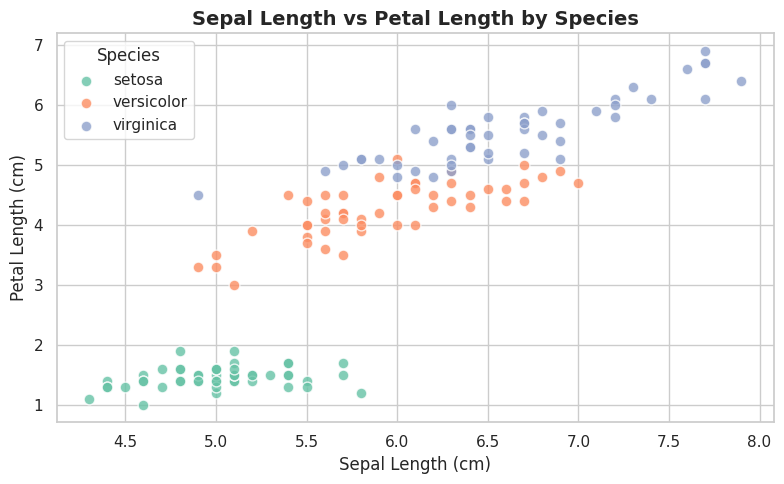

Figure 2 saved.


In [8]:
fig, ax = plt.subplots(figsize=(8, 5))

palette = {"setosa": "#66c2a5", "versicolor": "#fc8d62", "virginica": "#8da0cb"}
for species, group in df.groupby("species"):
    ax.scatter(group["sepal_length"], group["petal_length"],
               label=species, color=palette[species], s=60, alpha=0.8, edgecolors="white")

ax.set_title("Sepal Length vs Petal Length by Species", fontsize=14, fontweight="bold")
ax.set_xlabel("Sepal Length (cm)", fontsize=12)
ax.set_ylabel("Petal Length (cm)", fontsize=12)
ax.legend(title="Species")
plt.tight_layout()
plt.savefig("figure2_sepal_vs_petal.png", dpi=150)
plt.show()
print("Figure 2 saved.")

**Interpretation:** The scatter plot shows a strong positive relationship between sepal length
and petal length across all species (overall Pearson r ≈ 0.87). The three species cluster into
clearly defined regions: *setosa* occupies the lower-left (short sepals and petals), while
*virginica* occupies the upper-right. The visual separation supports the idea that both
measurements together are highly informative for species identification.

### Figure 3 — Feature Correlation Heatmap

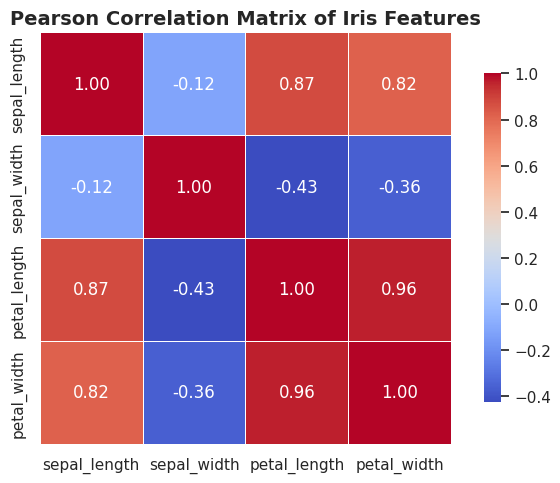

Figure 3 saved.


In [9]:
fig, ax = plt.subplots(figsize=(7, 5))

sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm",
            linewidths=0.5, ax=ax, square=True,
            cbar_kws={"shrink": 0.8})

ax.set_title("Pearson Correlation Matrix of Iris Features", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("figure3_correlation_heatmap.png", dpi=150)
plt.show()
print("Figure 3 saved.")

**Interpretation:** The heatmap confirms strong positive correlations between petal length,
petal width, and sepal length (r > 0.87), indicating that flowers with longer petals also tend
to have wider petals and longer sepals. Sepal width shows a weak or slightly negative correlation
with the other features, suggesting it carries independent information. These correlation patterns
guide feature selection decisions in future ML work.

## Summary and Interpretation

### Key Findings

The Iris dataset is a clean, well-structured dataset with 150 observations and four numeric measurements
across three balanced species classes. After deduplication and missing-value checks, the dataset required
no substantive corrections, confirming its widely known quality.

Exploratory analysis revealed that **petal dimensions** (length and width) are the most discriminating
features among the three species: *Iris setosa* is clearly separable from the other two by petal
measurements alone, while *versicolor* and *virginica* show some overlap in the petal-length range
of 4–5 cm. Sepal width, by contrast, exhibits the weakest between-species variation and a near-zero
correlation with petal features.

The strong correlation between petal length and petal width (r = 0.96) suggests that these two features
carry largely redundant information — a consideration relevant for dimensionality reduction (e.g., PCA)
in future projects.

### Limitations and Assumptions

- The dataset is small (150 rows) and perfectly balanced, which is atypical of real-world biological
  or industrial datasets. Models trained on it may not generalise to imbalanced or noisier settings.
- All four features are continuous measurements; no categorical or text features are present, so the
  cleaning pipeline does not cover string normalisation or encoding — steps that would be needed in
  richer datasets.
- Median imputation was applied as a precaution, but since the dataset had no missing values, its
  effect was null. In future projects where missingness is structural (e.g., sensor dropout), more
  sophisticated imputation strategies (KNN, MICE) should be considered.
- Outliers were not explicitly removed. The boxplot of sepal width shows a small number of high-value
  points in the *setosa* class; these were retained because they appear to be legitimate biological
  variation rather than measurement error.

### Surprising or Unclear Observations

Unexpectedly, *Iris setosa* has a **wider sepal on average** than the other two species despite
having the smallest petals overall — a counter-intuitive pattern that highlights how individual
features can diverge from the overall size trend of a flower.